In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Style settings for clean charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Connect to our database
conn = sqlite3.connect('briefing_data.db')
print("✅ Connected to database")


✅ Connected to database


In [2]:
df = pd.read_sql_query("SELECT * FROM emails", conn)

print(f"Total emails in database: {len(df)}")
df.head()


Total emails in database: 23


,id,subject,sender,date,snippet,category,urgency_score,people,dates,orgs,fetched_at
0,19edd6cf8219edf7,Add your latest expenses,Splitwise <hello@splitwise.com>,"Fri, 19 Jun 2026 01:09:26 +0000 (UTC)",Add your latest expenses ‌ ‌ ‌ ‌ ‌ ‌ ‌ ‌ ‌ ‌ ‌...,informational,0,,,,2026-06-19T09:45:58.302773
1,19edd5d441a35e30,Find out more about our updated Terms of Service,Google <google-noreply@google.com>,"Thu, 18 Jun 2026 17:52:17 -0700",jindalvartika9@gmail.com Every couple of years...,automated,0,,"30 July 2026, Every couple of years",Terms of Service,2026-06-19T09:45:58.302773
2,19edbe36e4f886fc,New message from Queens Of Change Foundation,Internshala Chat <no-reply-chat@updates.intern...,"Thu, 18 Jun 2026 17:59:34 +0000",New Message From Queens Of Change Foundation H...,automated,0,"Shreya, Vartika",,"Artificial Intelligence (AI) Internship, Queen...",2026-06-19T09:45:58.302773
3,19edbdb28ffb981d,Last chance savings: Start your skill-building...,Udemy <hello@students.udemy.com>,"Thu, 18 Jun 2026 17:50:32 +0000 (UTC)",Take a small step and work toward career rewar...,promotional,0,,,,2026-06-19T09:45:58.302773
4,19edb556d0d7ad72,New message from She Can Foundation,Internshala Chat <no-reply-chat@updates.intern...,"Thu, 18 Jun 2026 15:24:28 +0000",New Message From She Can Foundation Hi Vartika...,automated,0,,,"She Can Foundation New Message, She Can Founda...",2026-06-19T09:45:58.302773


In [3]:
print("Dataset Shape:", df.shape)
print("\nColumn Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (23, 11)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             23 non-null     object
 1   subject        23 non-null     object
 2   sender         23 non-null     object
 3   date           23 non-null     object
 4   snippet        23 non-null     object
 5   category       23 non-null     object
 6   urgency_score  23 non-null     int64 
 7   people         23 non-null     object
 8   dates          23 non-null     object
 9   orgs           23 non-null     object
 10  fetched_at     23 non-null     object
dtypes: int64(1), object(10)
memory usage: 2.1+ KB
None

Missing Values:
id               0
subject          0
sender           0
date             0
snippet          0
category         0
urgency_score    0
people           0
dates            0
orgs             0
fetched_at       0
dtype: int64


C:\Users\dell\AppData\Local\Temp\ipykernel_16916\1813814210.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')


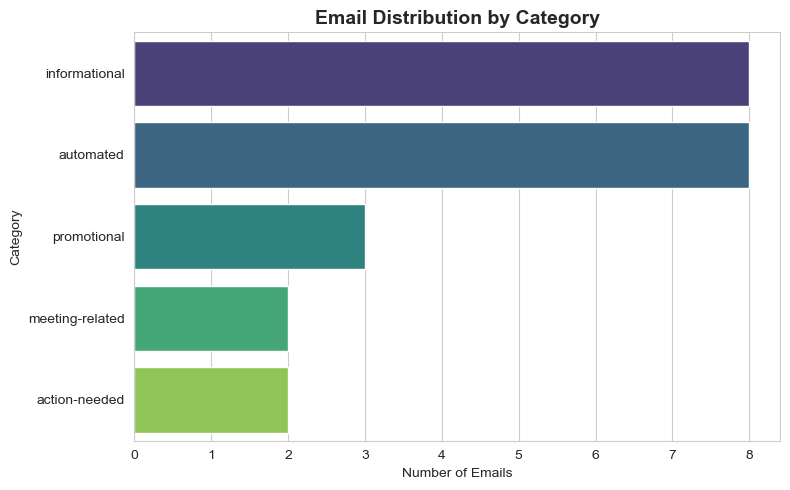

category
informational      8
automated          8
promotional        3
meeting-related    2
action-needed      2
Name: count, dtype: int64


In [4]:
category_counts = df['category'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')
plt.title('Email Distribution by Category', fontsize=14, fontweight='bold')
plt.xlabel('Number of Emails')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

print(category_counts)

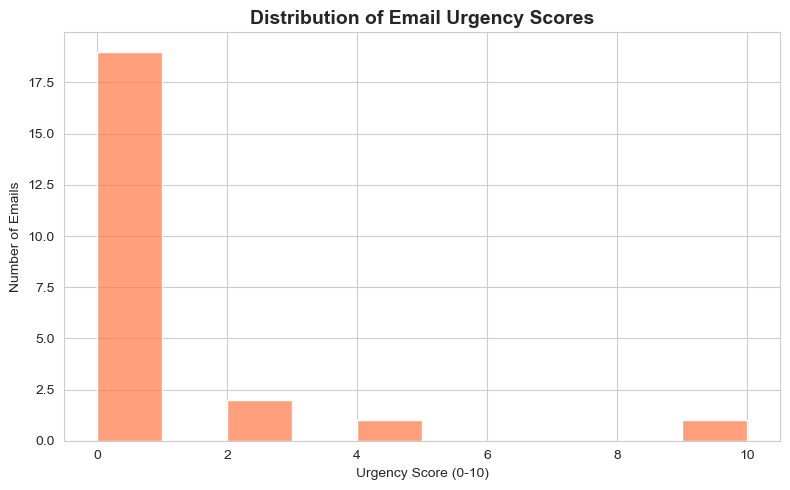

count    23.000000
mean      0.782609
std       2.235184
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max      10.000000
Name: urgency_score, dtype: float64


In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df['urgency_score'], bins=10, kde=False, color='coral')
plt.title('Distribution of Email Urgency Scores', fontsize=14, fontweight='bold')
plt.xlabel('Urgency Score (0-10)')
plt.ylabel('Number of Emails')
plt.tight_layout()
plt.show()

print(df['urgency_score'].describe())

C:\Users\dell\AppData\Local\Temp\ipykernel_16916\3193575906.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_senders.values, y=top_senders.index, palette='magma')


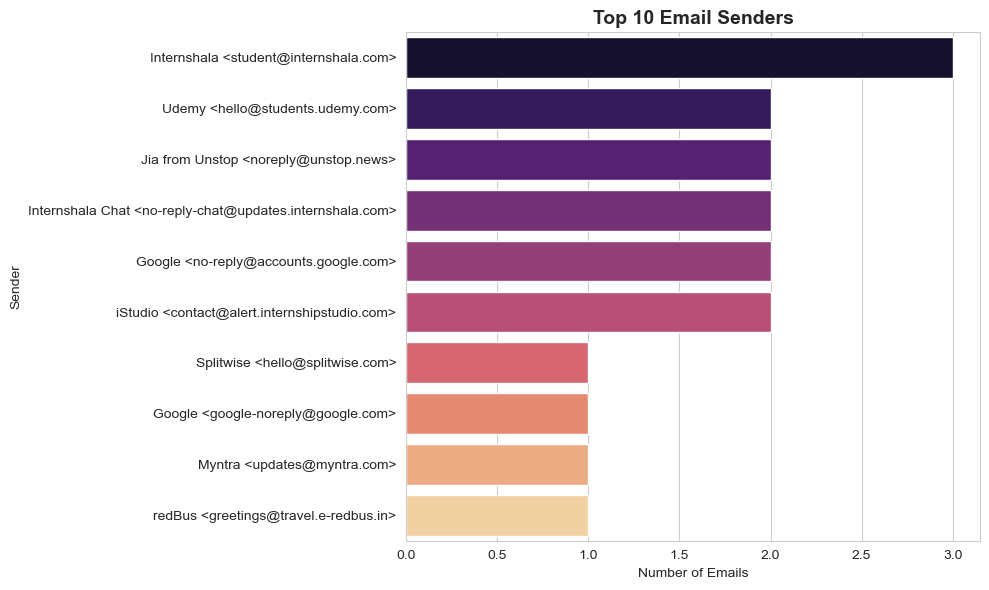

In [6]:
top_senders = df['sender'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_senders.values, y=top_senders.index, palette='magma')
plt.title('Top 10 Email Senders', fontsize=14, fontweight='bold')
plt.xlabel('Number of Emails')
plt.ylabel('Sender')
plt.tight_layout()
plt.show()


### Note on NER Limitations

The "People Mentioned" extraction above shows some false positives (e.g., "McLaren Racing", "Samsung Galaxy AI" classified as PERSON entities). This is a known limitation of running spaCy's NER on short, fragmented email snippets rather than full sentences — the model loses some of the contextual signal it relies on for accurate entity classification. In a production system, this could be improved with a custom-trained NER model fine-tuned on email-specific text, or a post-processing filter using a name-validation dictionary.

C:\Users\dell\AppData\Local\Temp\ipykernel_16916\253636332.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=people_counts.values, y=people_counts.index, palette='cool')
C:\Users\dell\AppData\Local\Temp\ipykernel_16916\253636332.py:11: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


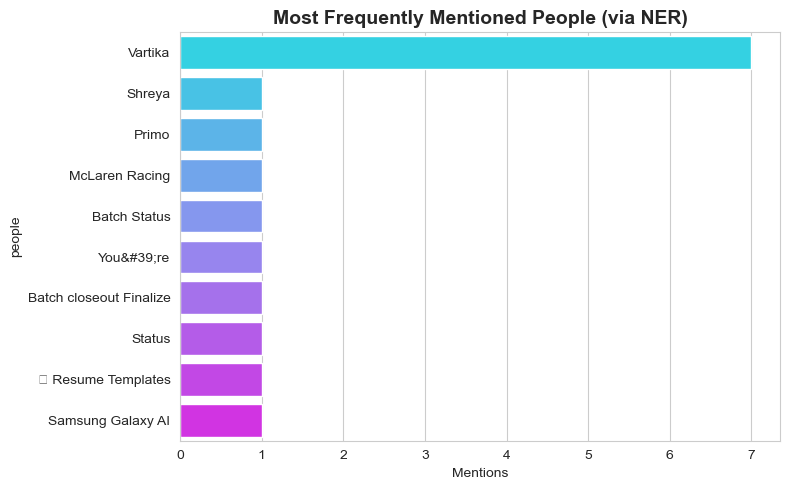

In [7]:
all_people = df['people'].str.split(', ').explode()
all_people = all_people[all_people != '']  # remove empty strings

if len(all_people) > 0:
    people_counts = all_people.value_counts().head(10)
    
    plt.figure(figsize=(8, 5))
    sns.barplot(x=people_counts.values, y=people_counts.index, palette='cool')
    plt.title('Most Frequently Mentioned People (via NER)', fontsize=14, fontweight='bold')
    plt.xlabel('Mentions')
    plt.tight_layout()
    plt.show()
else:
    print("No people entities found yet — need more data")

Average Urgency Score by Category:
                 mean  count
category                    
meeting-related   6.0      2
action-needed     3.0      2
automated         0.0      8
informational     0.0      8
promotional       0.0      3


C:\Users\dell\AppData\Local\Temp\ipykernel_16916\4186830511.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=urgency_by_category['mean'], y=urgency_by_category.index, palette='rocket')


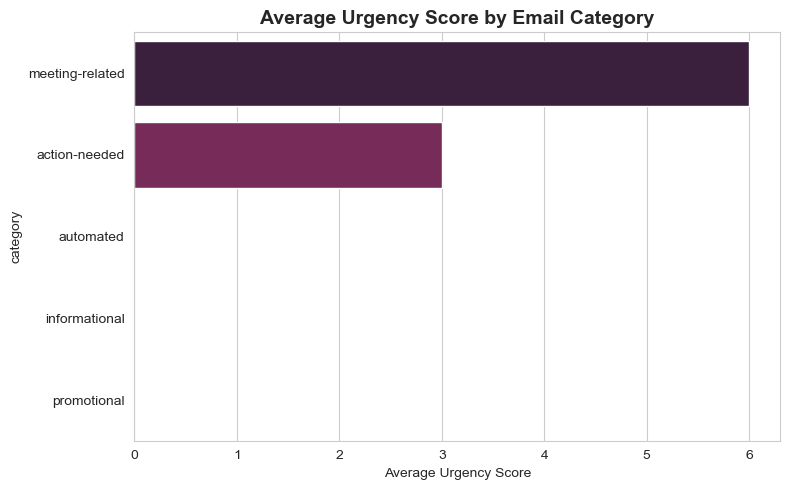

In [8]:
urgency_by_category = df.groupby('category')['urgency_score'].agg(['mean', 'count']).round(2)
urgency_by_category = urgency_by_category.sort_values('mean', ascending=False)

print("Average Urgency Score by Category:")
print(urgency_by_category)

plt.figure(figsize=(8, 5))
sns.barplot(x=urgency_by_category['mean'], y=urgency_by_category.index, palette='rocket')
plt.title('Average Urgency Score by Email Category', fontsize=14, fontweight='bold')
plt.xlabel('Average Urgency Score')
plt.tight_layout()
plt.show()

## Key Insights

- Out of 23 emails analyzed, the majority (74%) were categorized as informational or automated, reflecting typical day-to-day inbox noise rather than urgent items.
- The urgency scoring system shows strong validity: meeting-related emails averaged 6.0/10 urgency, action-needed emails averaged 3.0/10, while automated, informational, and promotional emails all averaged 0.0/10 — confirming the classifier correctly separates signal from noise.
- Internshala was the most frequent sender, reflecting heavy use of internship/career platforms during this period.
- NER-based entity extraction performs well on clearly mentioned names but shows reduced precision on fragmented snippet text — a documented limitation suitable for future improvement with a fine-tuned model.
- This analysis is based on a single day's email pull; a production version of this system would benefit from multi-day data collection to identify temporal response patterns and sender-specific behavior trends.